In [2]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torchvision import transforms
import torch.nn as nn
import pandas as pd
import numpy as np

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(device)

cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Resize to 32x32
    transforms.ToTensor(),  # Convert image to tensor
])

In [5]:
train_dataset = datasets.MNIST(
    root = "data",
    download = True,
    train = True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root = "data",
    download = True,
    train = False,
    transform=transform
)
print(train_dataset,test_dataset)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 54.5MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 2.04MB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           ) Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


0


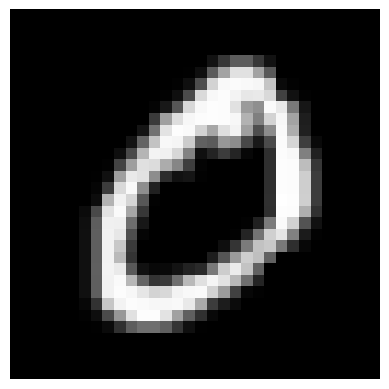

In [14]:
import matplotlib.pyplot as plt

# Assuming train_dataset[1][0] contains the image data as a PyTorch tensor
x = train_dataset[1]
image_data = x[0].numpy()  # Convert to NumPy array
print(x[1])
# Reshape the image data to 32x32 if necessary
image_data = image_data.reshape(32, 32)

# Display the image using matplotlib.pyplot
plt.imshow(image_data, cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')  # Turn off axis labels and ticks
plt.show()

In [ ]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

In [ ]:
bs = 64
train_dl = DataLoader(train_dataset,batch_size=bs,shuffle=True)
test_dl = DataLoader(test_dataset,batch_size=bs,shuffle=True)
print(len(train_dl),len(test_dl))

938 157


In [ ]:
class MNIST(nn.Module):
  def __init__(self):
    super().__init__()
    self.relu = nn.ReLU()
    self.C1 = nn.Conv2d(in_channels=1,out_channels=6,kernel_size=(5,5),padding=0)
    self.S2_S4 = nn.MaxPool2d(kernel_size=(2,2),stride=2)   #Applied in S2 and S4 same things so
    self.C3 = nn.Conv2d(in_channels=6,out_channels=16,kernel_size=(5,5),padding=0)
    self.C5 = nn.Conv2d(in_channels=16,out_channels=120,kernel_size=(5,5),padding=0)
    self.F6 = nn.Linear(in_features=120,out_features=84)
    self.Output = nn.Linear(in_features=84,out_features=10)
  def forward(self,x):
    x = self.C1(x)
    x = self.relu(x)
    x = self.S2_S4(x)
    x = self.C3(x)
    x = self.relu(x)
    x = self.S2_S4(x)
    x = self.C5(x)
    x = self.relu(x)
    x = x.reshape(x.shape[0],-1)
    x = self.F6(x)
    x = self.relu(x)
    x = self.Output(x)
    return x


In [ ]:
def train_one_epoch(dataloader,model,loss_fn,optimizer):
  model.train()
  total_loss = 0
  total_correct = 0
  for i,(image,lables) in enumerate(dataloader):
    image = image.to(device)
    lables = lables.to(device)
    pred = model(image)
    loss = loss_fn(pred,lables)
    total_loss += loss.item()
    total_correct += (pred.argmax(1) == lables).type(torch.float).sum().item()

    running_loss = round(total_loss / (i+(image.shape[0]/bs)),2)
    running_accuracy = round(total_correct /((i*bs+image.shape[0]))*100,2)

    loss.backward() # back propagation
    optimizer.step() # update parameters
    optimizer.zero_grad() # gradient decent to zero

    if i%100==0:
            print("Batch:", i+1, "/",len(dataloader), "Running Loss:",running_loss, "Running Accuracy:",running_accuracy)

  epoch_loss=running_loss
  epoch_acc=running_accuracy
  return epoch_loss, epoch_acc


In [ ]:
def eval_one_epoch(dataloader, model,loss_fn):
    model.eval()
    track_loss=0
    num_correct=0
    with torch.no_grad():
        for i, (imgs, labels) in enumerate(dataloader):
            imgs=imgs.to(device)
            labels=labels.to(device)
            pred=model(imgs)
            loss=loss_fn(pred,labels)
            track_loss+=loss.item()
            num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()
            running_loss=round(track_loss/(i+(imgs.shape[0]/bs)),2)
            running_acc=round((num_correct/((i*bs+imgs.shape[0])))*100,2)

            if i%100==0:
                print("Batch:", i+1, "/",len(dataloader), "Running Loss:",running_loss, "Running Accuracy:",running_acc)

    epoch_loss=running_loss
    epoch_acc=running_acc
    return epoch_loss, epoch_acc

In [ ]:
model=MNIST()
model=model.to(device)
loss_fn=nn.CrossEntropyLoss()
lr=0.001
optimizer=torch.optim.Adam(params=model.parameters(), lr=lr)
n_epochs=30

for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=train_one_epoch(train_dl,model,loss_fn,optimizer)
    val_epoch_loss, val_epoch_acc=eval_one_epoch(test_dl,model,loss_fn)
    print("Training:", "Epoch Loss:", train_epoch_loss, "Epoch Accuracy:", train_epoch_acc)
    print("Inference:", "Epoch Loss:", val_epoch_loss, "Epoch Accuracy:", val_epoch_acc)
    print("--------------------------------------------------")

Epoch No: 1
Batch: 1 / 938 Running Loss: 2.3 Running Accuracy: 7.81
Batch: 101 / 938 Running Loss: 1.15 Running Accuracy: 64.06
Batch: 201 / 938 Running Loss: 0.75 Running Accuracy: 76.88
Batch: 301 / 938 Running Loss: 0.59 Running Accuracy: 81.66
Batch: 401 / 938 Running Loss: 0.5 Running Accuracy: 84.63
Batch: 501 / 938 Running Loss: 0.43 Running Accuracy: 86.59
Batch: 601 / 938 Running Loss: 0.39 Running Accuracy: 88.08
Batch: 701 / 938 Running Loss: 0.35 Running Accuracy: 89.23
Batch: 801 / 938 Running Loss: 0.32 Running Accuracy: 90.12
Batch: 901 / 938 Running Loss: 0.3 Running Accuracy: 90.86
Batch: 1 / 157 Running Loss: 0.03 Running Accuracy: 98.44
Batch: 101 / 157 Running Loss: 0.09 Running Accuracy: 97.12
Training: Epoch Loss: 0.29 Epoch Accuracy: 91.06
Inference: Epoch Loss: 0.08 Epoch Accuracy: 97.36
--------------------------------------------------
Epoch No: 2
Batch: 1 / 938 Running Loss: 0.11 Running Accuracy: 96.88
Batch: 101 / 938 Running Loss: 0.1 Running Accuracy: 97.

In [ ]:
torch.save(model.state_dict(), "CNN_LeNet5_complete_model.pth")
print("Model saved successfully!")

Model saved successfully!
